In [6]:
# ==============================================================
# NIPT Fetal Anomaly Prediction Using Machine Learning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.decomposition import PCA
from scipy.stats import zscore
from imblearn.over_sampling import SMOTE

try:
    import lightgbm as lgb
except:
    print("LightGBM not installed; using Logistic Regression only.")

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

LightGBM not installed; using Logistic Regression only.


In [7]:
# =========================
# File Paths
# =========================
BASE_PATH = r"C:\Users\13725\Desktop\数学建模竞赛\2025C"
MALE_FILE = f"{BASE_PATH}\\Y染色体分析数据.csv"
FEMALE_FILE = f"{BASE_PATH}\\附件.xlsx"

In [8]:
# ==============================================================
# Male Fetal Data Analysis
# ==============================================================

df_male = pd.read_csv(MALE_FILE, encoding='gbk')

def auto_col(df, keywords):
    for c in df.columns:
        if any(kw in c for kw in keywords):
            return c
    return None

gest_col = auto_col(df_male, ['孕周', '检测孕周'])
bmi_col = auto_col(df_male, ['BMI', '体重指数'])
y_col = auto_col(df_male, ['Y染色体浓度', 'Y浓度'])

def convert_gest(x):
    try:
        x = str(x).upper()
        if '+' in x:
            w, d = x.split('+')
            return round(int(w.replace('W','')) + int(d)/7, 2)
        return round(float(x.replace('W','')), 2)
    except:
        return np.nan

df_male['gest_week'] = df_male[gest_col].apply(convert_gest)
df_male = df_male.dropna(subset=[bmi_col, y_col, 'gest_week'])

corr_p = df_male[bmi_col].corr(df_male[y_col], method='pearson')
corr_s = df_male[bmi_col].corr(df_male[y_col], method='spearman')
print(f"Pearson: {corr_p:.3f} | Spearman: {corr_s:.3f}")

Pearson: -0.154 | Spearman: -0.157


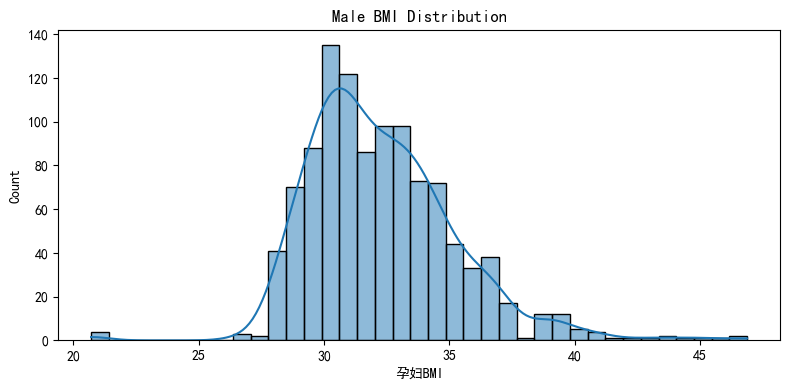

In [9]:
# Male BMI Distribution
plt.figure(figsize=(8,4))
sns.histplot(df_male[bmi_col], kde=True)
plt.title("Male BMI Distribution")
plt.tight_layout()
plt.savefig(f"{BASE_PATH}\\male_bmi.png", dpi=300)
plt.show()

In [10]:
# Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(df_male[[bmi_col]])
y_target = df_male[y_col]
reg = LinearRegression()

try:
    reg.fit(X_poly, y_target)
except:
    print("Regression skipped")

In [11]:
# ==============================================================
# Female Fetal Analysis & Anomaly Detection
# ==============================================================

df_female = pd.read_excel(FEMALE_FILE)

features = [
    '年龄', '体重', '孕妇BMI', 'GC含量',
    '13号染色体的GC含量', '18号染色体的GC含量', '21号染色体的GC含量',
    '被过滤掉读段数的比例', 'X染色体浓度', 'Y染色体浓度'
]

X = df_female[features].fillna(df_female.median(numeric_only=True))

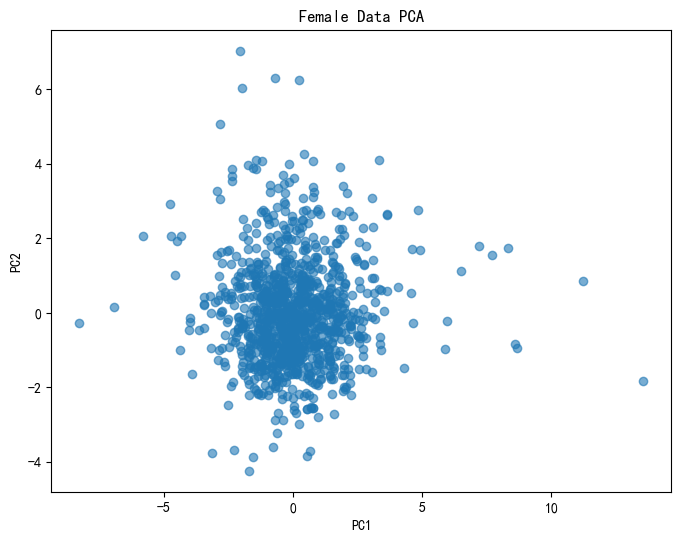

In [12]:
# PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Female Data PCA')
plt.savefig(BASE_PATH + '\\female_pca.png', dpi=300)
plt.show()

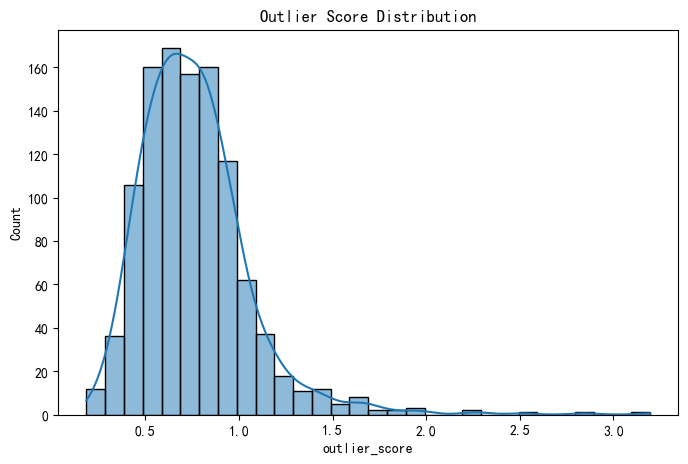

In [13]:
# Outlier Score
z_scores = np.abs(zscore(X_scaled))
df_female['outlier_score'] = z_scores.mean(axis=1)

plt.figure(figsize=(8,5))
sns.histplot(df_female['outlier_score'], bins=30, kde=True)
plt.title('Outlier Score Distribution')
plt.savefig(BASE_PATH + '\\female_outlier_score.png', dpi=300)
plt.show()

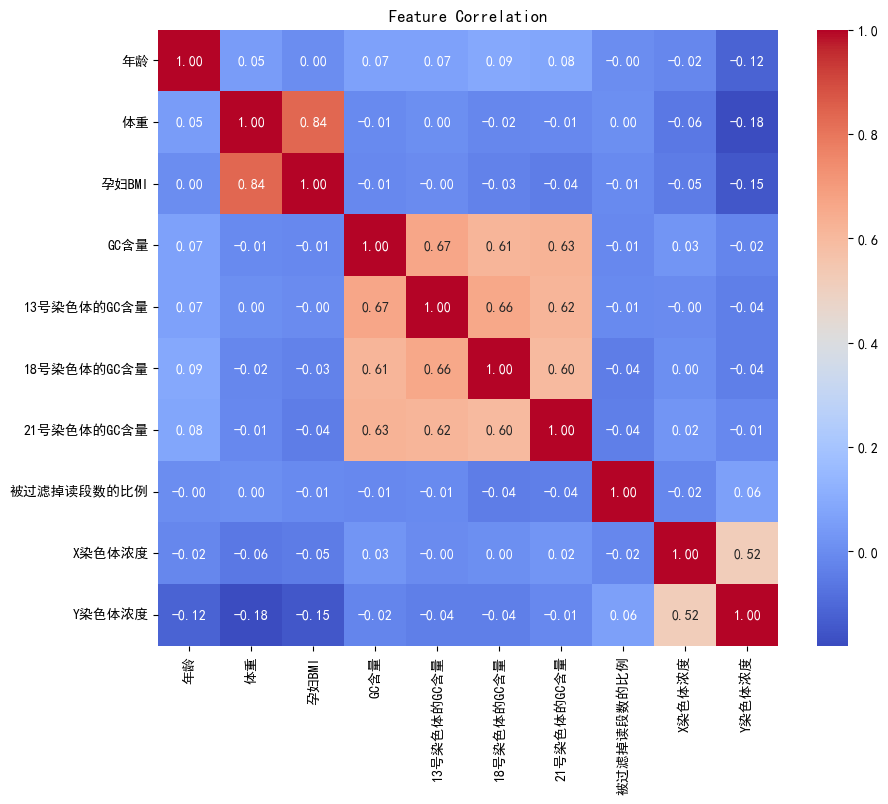

In [14]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation')
plt.savefig(BASE_PATH + '\\female_corr_heatmap.png', dpi=300)
plt.show()

In [15]:
# ==============================================================
# Classification (only if labels are valid)
# ==============================================================

df_female['is_abnormal'] = df_female['胎儿是否健康'].apply(lambda x: 0 if '健康' in str(x) else 1)
y = df_female['is_abnormal']

if len(y.unique()) >= 2:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    try:
        smote = SMOTE(random_state=42)
        X_train, y_train = smote.fit_resample(X_train, y_train)
    except:
        print("SMOTE skipped")

    models = {
        "Logistic Regression": LogisticRegression(max_iter=2000),
    }

    try:
        models["LightGBM"] = lgb.LGBMClassifier(random_state=42)
    except:
        pass

    results = []
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]

        acc = accuracy_score(y_test, y_pred)
        pre = precision_score(y_test, y_pred, zero_division=1)
        rec = recall_score(y_test, y_pred, zero_division=1)
        f1 = f1_score(y_test, y_pred, zero_division=1)
        auc = roc_auc_score(y_test, y_prob)
        results.append([name, acc, pre, rec, f1, auc])

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.figure(figsize=(6,6))
        plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
        plt.plot([0,1],[0,1],'k--')
        plt.title(f'ROC - {name}')
        plt.legend()
        plt.savefig(f"{BASE_PATH}/roc_{name.lower().replace(' ','_')}.png", dpi=300)
        plt.show()

    res_df = pd.DataFrame(results, columns=["Model","Acc","Prec","Recall","F1","AUC"])
    print(res_df.round(3))

else:
    print("All samples are healthy; classification skipped.")

All samples are healthy; classification skipped.
